# Spatial market animation & run analysis

Loads a finished Phase-0 Q-learning run, summarises convergence and per-store
price dynamics, renders static choropleth snapshots and a GIF animation of the
Berlin spatial market using `hotelling.viz.spatial_map`, and exposes an
ipywidgets slider for interactive exploration.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

# -- Robustly locate the repository root (dir that contains 'src') --------
def _find_repo_root(start: Path) -> Path:
    """Walk up from *start* until we find a directory that contains 'src'."""
    for p in [start, *start.parents]:
        if (p / "src").is_dir():
            return p
    raise RuntimeError(f"Could not find a 'src' directory above {start}")

repo_root = _find_repo_root(Path.cwd())
_src = str(repo_root / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

print(f"repo_root : {repo_root}")
print(f"sys.path  : {_src}")

%matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import Image, HTML, display

from hotelling.viz.spatial_map import (
    load_run,
    prices_efforts_at,
    plot_market_snapshot,
    animate_market,
    interactive_slider,
)
from hotelling.simulation.dense_log import DenseLog
from hotelling.core.market import cell_metrics

repo_root : /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling
sys.path  : /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling/src


In [2]:
# Override: set to a specific Path (or string) to pin a run.
RUN_DIR = None  # e.g. repo_root / "results" / "runs" / "20260528_035250_a530d7f6"

# -- Auto-detect latest finished run ----------------------------------------
if RUN_DIR is None:
    _index = repo_root / "results" / "index.csv"
    if _index.exists():
        _idx = pd.read_csv(_index)
        _run_name = str(_idx.iloc[-1]["run_name"])
        RUN_DIR = repo_root / "results" / "runs" / _run_name
    else:
        # Fallback: most recently modified subdir containing dense_log_meta.json
        _runs_root = repo_root / "results" / "runs"
        _candidates = [
            d for d in _runs_root.iterdir()
            if d.is_dir() and (d / "dense_log_meta.json").exists()
        ]
        if not _candidates:
            raise FileNotFoundError(
                f"No finished run directories found under {_runs_root}.\n"
                "Run  python scripts/run_baseline.py  first."
            )
        RUN_DIR = max(_candidates, key=lambda d: d.stat().st_mtime)

RUN_DIR = Path(RUN_DIR)
print(f"RUN_DIR : {RUN_DIR}")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"
assert (RUN_DIR / "dense_log_meta.json").exists(), (
    f"dense_log_meta.json missing from {RUN_DIR}. Is the run complete?"
)
print("\u2713 Run directory looks complete.")

RUN_DIR : /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/DEDA Project/DEDA_LLM_Spatial_Hotelling/results/runs/20260602_223427_91e6bd4f
✓ Run directory looks complete.


## Run metadata

Loads `dense_log_meta.json`, `metadata.json`, and `config.yaml` from the run
directory and prints a compact summary.

- **`m_effort == 1`** → price-only Calvano baseline; effort is frozen at 0.
- **`m_effort > 1`** → effort is an active learned choice; verify calibration
  with `scripts/check_effort_calibration.py` before drawing conclusions.

In [3]:
# -- Load dense_log meta ---------------------------------------------------
with (RUN_DIR / "dense_log_meta.json").open() as _f:
    _dense_meta = json.load(_f)

T_written = int(_dense_meta.get("T_written", _dense_meta.get("T_allocated", 0)))
N_agents  = int(_dense_meta.get("N", 0))

# -- Load metadata and config (may be absent for very old runs) ------------
_meta_path = RUN_DIR / "metadata.json"
_meta = json.loads(_meta_path.read_text()) if _meta_path.exists() else {}

_cfg_path = RUN_DIR / "config.yaml"
_cfg = yaml.safe_load(_cfg_path.read_text()) if _cfg_path.exists() else {}
_env_cfg    = _cfg.get("env", _cfg)
_agents_cfg = _cfg.get("agents", {})

m_effort = int(_agents_cfg.get("m_effort", 1))

summary = pd.Series(
    {
        "n_firms"          : N_agents,
        "T_written"        : T_written,
        "m_effort"         : m_effort,
        "delta"            : _meta.get("delta",            float("nan")),
        "p_nash"           : _meta.get("p_nash",           float("nan")),
        "p_mono"           : _meta.get("p_mono",           float("nan")),
        "mean_final_price" : _meta.get("mean_final_price", float("nan")),
        "converged"        : _meta.get("converged",        "?"),
        "transport_cost"   : _env_cfg.get("transport_cost", float("nan")),
        "mu"               : _env_cfg.get(
            "mu", _env_cfg.get("logit_scale", float("nan"))
        ),
    },
    name="value",
)
display(summary.to_frame())

# -- Effort mode banner ----------------------------------------------------
if m_effort == 1:
    print("\u2691  Effort mode: FROZEN (m_effort=1) — price-only Calvano baseline.")
else:
    _m_price = int(_agents_cfg.get("m", 15))
    print(
        f"\u2691  Effort mode: ACTIVE (m_effort={m_effort}) — joint action space "
        f"{_m_price}×{m_effort} = {_m_price * m_effort} per agent."
    )

,value
n_firms,494
T_written,1000000
m_effort,1
delta,0.368479
p_nash,0.714821
p_mono,0.892128
mean_final_price,0.780155
converged,True
transport_cost,0.5
mu,0.25


⚑  Effort mode: FROZEN (m_effort=1) — price-only Calvano baseline.


## Aggregate convergence

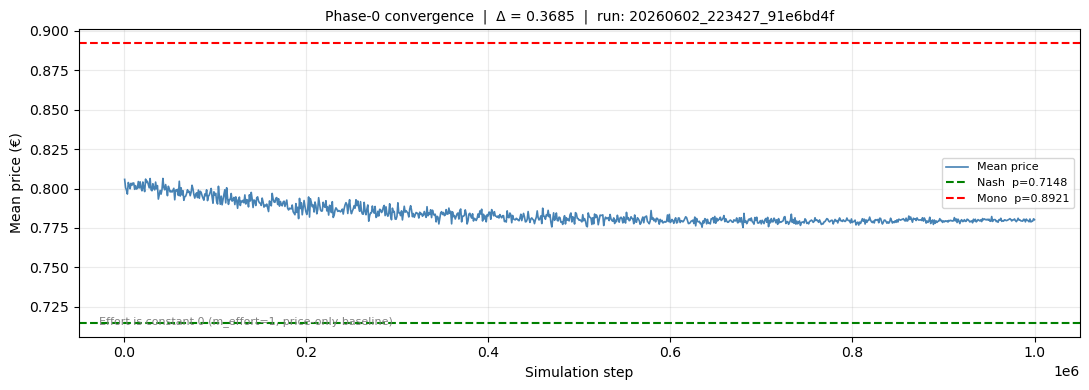

In [4]:
_agg_path = RUN_DIR / "aggregate.parquet"
if not _agg_path.exists():
    print(f"aggregate.parquet not found at {_agg_path}. Skipping convergence plot.")
else:
    _agg    = pd.read_parquet(_agg_path)
    _p_nash = _meta.get("p_nash", None)
    _p_mono = _meta.get("p_mono", None)
    _delta  = _meta.get("delta",  float("nan"))

    _has_effort_col = m_effort > 1 and "mean_effort" in _agg.columns

    if _has_effort_col:
        _fig, (_ax1, _ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    else:
        _fig, _ax1 = plt.subplots(figsize=(11, 4))

    _ax1.plot(_agg["step"], _agg["mean_price"],
              lw=1.2, color="steelblue", label="Mean price")
    if _p_nash is not None:
        _ax1.axhline(_p_nash, ls="--", lw=1.5, color="green",
                     label=f"Nash  p={_p_nash:.4f}")
    if _p_mono is not None:
        _ax1.axhline(_p_mono, ls="--", lw=1.5, color="red",
                     label=f"Mono  p={_p_mono:.4f}")
    _ax1.set_ylabel("Mean price (\u20ac)")
    _ax1.legend(fontsize=8)
    _ax1.grid(alpha=0.25)
    _ax1.set_title(
        f"Phase-0 convergence  |  \u0394 = {_delta:.4f}  |  run: {RUN_DIR.name}",
        fontsize=10,
    )

    if _has_effort_col:
        _ax2.plot(_agg["step"], _agg["mean_effort"],
                  lw=1.2, color="darkorange", label="Mean effort")
        _ax2.set_xlabel("Simulation step")
        _ax2.set_ylabel("Mean effort")
        _ax2.legend(fontsize=8)
        _ax2.grid(alpha=0.25)
    else:
        _ax1.set_xlabel("Simulation step")
        if m_effort == 1:
            _ax1.annotate(
                "Effort is constant 0 (m_effort=1, price-only baseline)",
                xy=(0.02, 0.04), xycoords="axes fraction",
                fontsize=8, color="grey",
            )

    _fig.tight_layout()
    plt.show()

## Per-store price distribution

Final-step price histogram, cross-store dispersion bands over time, and
mean converged price by chain type.

In [ ]:
import geopandas as gpd

dl = DenseLog.load(RUN_DIR)

# Memory guard: if the full log is very large, use a strided subset of periods.
_TOTAL_CELLS = dl._rows_written * len(dl.agent_ids)
if _TOTAL_CELLS > 5_000_000:
    _stride_df = max(1, dl._rows_written // (5_000_000 // max(1, len(dl.agent_ids))))
    print(
        f"Log is large ({_TOTAL_CELLS:,} cells). "
        f"Building DataFrame for every {_stride_df} steps (strided subset)."
    )
    df = dl.to_dataframe(step_slice=slice(0, dl._rows_written, _stride_df))
else:
    df = dl.to_dataframe()

print(f"DenseLog: T={dl._rows_written:,} steps, N={dl.N} stores, m_effort={m_effort}")
print(f"DataFrame: {len(df):,} rows  (columns: {list(df.columns)})")

# -- Load chain labels (join on agent_id == store row index j) ------------
_stores_path = Path(_env_cfg.get("stores_path",
                     "data/processed/supermarkets.parquet"))
if not _stores_path.is_absolute():
    _stores_path = repo_root / _stores_path

if _stores_path.exists():
    _stores_gdf = gpd.read_parquet(_stores_path).reset_index(drop=True)
    _chain_col  = (
        "chain_type" if "chain_type" in _stores_gdf.columns
        else "chain" if "chain" in _stores_gdf.columns
        else None
    )
    if _chain_col:
        _chain_map = _stores_gdf[_chain_col].astype(str)
        df["chain"] = df["agent_id"].apply(
            lambda aid: _chain_map.iloc[int(aid)]
            if str(aid).isdigit() and int(aid) < len(_chain_map)
            else "unknown"
        )
else:
    print(f"Stores parquet not found at {_stores_path}; skipping chain labels.")

# -- Plots -----------------------------------------------------------------
_fig, _axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Final-step price histogram
_t_max   = df["period"].max()
_df_final = df[df["period"] == _t_max]
_axes[0].hist(_df_final["price"], bins=20,
              color="steelblue", edgecolor="white", linewidth=0.5)
_axes[0].set_xlabel("Price (€)")
_axes[0].set_ylabel("Count")
_axes[0].set_title(f"Price distribution at t={_t_max:,}")
_axes[0].grid(alpha=0.25)

# (b) Price dispersion over time: p10/p50/p90 bands + std overlay
_price_stats = df.groupby("period")["price"].agg(
    p10=lambda x: x.quantile(0.10),
    p50=lambda x: x.quantile(0.50),
    p90=lambda x: x.quantile(0.90),
    std="std",
)
_axes[1].fill_between(
    _price_stats.index, _price_stats["p10"], _price_stats["p90"],
    alpha=0.25, color="steelblue", label="p10–p90"
)
_axes[1].plot(_price_stats.index, _price_stats["p50"],
              lw=1.2, color="steelblue", label="Median")
_ax_std = _axes[1].twinx()
_ax_std.plot(_price_stats.index, _price_stats["std"],
             lw=0.8, ls=":", color="darkorange", label="Std")
_ax_std.set_ylabel("Std (€)", color="darkorange", fontsize=8)
_axes[1].set_xlabel("Step")
_axes[1].set_ylabel("Price (€)")
_axes[1].set_title("Price dispersion over time")
_axes[1].legend(fontsize=8, loc="upper left")
_axes[1].grid(alpha=0.25)

# (c) Per chain_type mean final price
if "chain" in df.columns:
    _chain_means = _df_final.groupby("chain")["price"].mean().sort_values()
    _chain_means.plot.barh(ax=_axes[2], color="steelblue", edgecolor="white")
    _axes[2].set_xlabel("Mean final price (€)")
    _axes[2].set_title("Mean final price by chain type")
    _axes[2].grid(alpha=0.25, axis="x")
else:
    _axes[2].text(
        0.5, 0.5, "Chain labels unavailable\n(stores parquet not found)",
        ha="center", va="center", transform=_axes[2].transAxes, color="grey",
    )
    _axes[2].set_title("Mean final price by chain type")

_fig.tight_layout()
plt.show()

Log is large (494,000,000 cells). Building DataFrame for every 98 steps (strided subset).
DenseLog: T=1,000,000 steps, N=494 stores, m_effort=1
DataFrame: 5,041,270 rows  (columns: ['period', 'agent_id', 'price_idx', 'effort_idx', 'price', 'effort', 'demand', 'profit'])


## Static spatial snapshots

One frame at `t = 0`, `T//2`, and `T-1` with the `expected_price` choropleth.
An additional `dominant_chain` frame is rendered at `t = T-1`.

In [ ]:
_figures_dir = RUN_DIR / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

T = T_written  # from dense_log_meta loaded in cell 3

# Snapshots: (time_step, metric) pairs
_snapshots = [
    (0,        "expected_price"),
    (T // 2,   "expected_price"),
    (T - 1,    "expected_price"),
    (T - 1,    "dominant_chain"),
]

for _t, _metric in _snapshots:
    _save = _figures_dir / f"snapshot_t{_t}_{_metric}.png"
    _fig = plot_market_snapshot(
        RUN_DIR,
        _t,
        metric=_metric,
        save_path=_save,
        point_size_by_demand=True,
    )
    print(f"Saved: {_save}")
    display(_fig)
    plt.close(_fig)

## Spatial animation

Creates a GIF of the `expected_price` choropleth over the full run.
The animation is written to `RUN_DIR/animation.gif` which lives under
`results/` (gitignored) and is **never** embedded in the notebook.

> **Tip:** pass `save_path=...'animation.mp4'` for H.264 video (requires
> `ffmpeg` on `PATH`). The GIF is the zero-dependency default.
>
> Frame count ≈ 60–120 via `stride = max(1, T // 80)` keeps file size and
> render time reasonable.

In [ ]:
T = T_written  # from dense_log_meta

gif_path = animate_market(
    RUN_DIR,
    metric="expected_price",
    stride=max(1, T // 360),
    fps=10,
    save_path=RUN_DIR / "animation.gif",
)
print(
    f"Animation written to: {gif_path}  "
    "(under results/ \u2192 gitignored, not committed)"
)

## Interactive slider

Requires an interactive matplotlib backend — either `%matplotlib widget`
(JupyterLab + `ipympl`) or classic `%matplotlib notebook`.

With the default `inline` backend each slider move re-renders a complete
frame; this works but is slow. **Prefer the GIF above for sharing; use the
slider for ad-hoc inspection.**

The call is wrapped in `try/except` so the notebook runs cleanly when
`ipywidgets` is absent.

In [ ]:
# Switch to an interactive backend for smooth slider response:
#   %matplotlib widget    (JupyterLab + pip install ipympl)
#   %matplotlib notebook  (classic Jupyter)
# Leave as-is to use the inline backend (one full redraw per move).

try:
    interactive_slider(RUN_DIR, metric="expected_price")
except ImportError as _err:
    print(
        f"ipywidgets not available ({_err}).\n"
        "Install with:  pip install 'hotelling[notebooks]'"
    )

## Outputs

| Artefact | Location |
|---|---|
| Per-step snapshots | `RUN_DIR/figures/snapshot_t*_*.png` |
| Animation GIF | `RUN_DIR/animation.gif` |

Everything under `results/` is gitignored — animation files and snapshots
are never committed to the repository.